In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver
import warnings
warnings.filterwarnings('ignore')

# ─── LNOI Rib Waveguide Parameters ───
wavelength = 1.55          # µm (telecom C-band)
freq       = td.C_0 / wavelength

# Film stack (your actual wafer)
n_LN       = 2.2           # LN refractive index at 1550 nm (isotropic approx)
n_SiO2     = 1.44          # SiO2 at 1550 nm
rib_w      = 0.8           # um rib width
rib_h      = 0.2           # um rib height (above slab)
slab_w     = 5.6           # um slab width
slab_h     = 0.1           # um slab thickness
film_h     = slab_h + rib_h  # 0.3 um total LN at rib center
box_h      = 2.0           # um buried oxide thickness

mat_LN     = td.Medium(permittivity=n_LN**2)
mat_SiO2   = td.Medium(permittivity=n_SiO2**2)

print('=' * 50)
print('LNOI Rib Waveguide - Bend Radius Analysis')
print('=' * 50)
print(f'Wavelength : {wavelength*1e3:.0f} nm')
print(f'LN film    : {film_h*1e3:.0f} nm total, {slab_h*1e3:.0f} nm slab, {rib_h*1e3:.0f} nm rib')
print(f'Slab width : {slab_w} um')
print(f'Rib width  : {rib_w} um')
print(f'BOX        : {box_h} um SiO2')

17:35:13 Eastern Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\prava\.config\tidy3d'. Found legacy 
                               directory at '~/.tidy3d', which will be ignored. 
                               Remove it manually or run 'tidy3d config migrate 
                               --delete-legacy' to clean up.

LNOI Rib Waveguide - Bend Radius Analysis
Wavelength : 1550 nm
LN film    : 300 nm total, 100 nm slab, 200 nm rib
Slab width : 5.6 um
Rib width  : 0.8 um
BOX        : 2.0 um SiO2


17:35:16 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

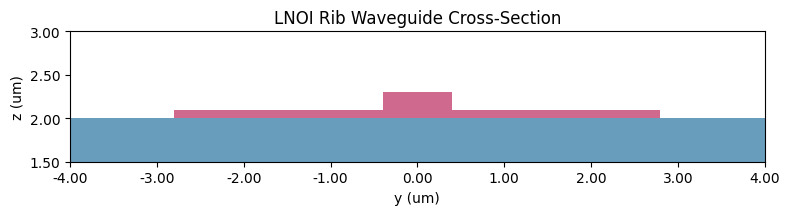

In [2]:
# ─── Build waveguide cross-section geometry ───
# z=0 at bottom of BOX; rib sits on top of slab
box_struct  = td.Structure(
    geometry=td.Box(center=(0, 0, box_h/2),
                    size=(td.inf, td.inf, box_h)),
    medium=mat_SiO2, name='BOX')

slab_struct = td.Structure(
    geometry=td.Box(center=(0, 0, box_h + slab_h/2),
                    size=(td.inf, slab_w, slab_h)),
    medium=mat_LN, name='slab')

rib_struct  = td.Structure(
    geometry=td.Box(center=(0, 0, box_h + slab_h + rib_h/2),
                    size=(td.inf, rib_w, rib_h)),
    medium=mat_LN, name='rib')

sim = td.Simulation(
    size=(1, 10, 4),
    center=(0, 0, 2.0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=25, wavelength=wavelength),
    structures=[box_struct, slab_struct, rib_struct],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)

# Plot cross-section
fig, ax = plt.subplots(figsize=(8, 4))
sim.plot(x=0, ax=ax)
ax.set_xlim(-4, 4)
ax.set_ylim(1.5, 3.0)
ax.set_xlabel('y (um)')
ax.set_ylabel('z (um)')
ax.set_title('LNOI Rib Waveguide Cross-Section')
plt.tight_layout()
plt.show()

In [3]:
# ─── Compute straight waveguide mode + slab-only mode ───
plane = td.Box(center=(0, 0, 2.15), size=(0, 8, 2.5))

# Fundamental mode of the full rib waveguide (straight)
ms_straight = ModeSolver(
    simulation=sim, plane=plane,
    mode_spec=td.ModeSpec(num_modes=3, target_neff=n_LN),
    freqs=[freq],
)
md_straight = ms_straight.solve()

print('Straight rib waveguide modes:')
for i in range(3):
    n = np.real(md_straight.n_eff.values[0, i])
    print(f'  Mode {i}: n_eff = {n:.6f}')

n_eff_fund = np.real(md_straight.n_eff.values[0, 0])

# Slab-only mode (no rib) — sets the lateral confinement baseline
slab_only_sim = td.Simulation(
    size=(1, 10, 4), center=(0, 0, 2.0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=25, wavelength=wavelength),
    structures=[box_struct, slab_struct],   # no rib!
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)
ms_slab = ModeSolver(
    simulation=slab_only_sim, plane=plane,
    mode_spec=td.ModeSpec(num_modes=1, target_neff=n_LN),
    freqs=[freq],
)
md_slab = ms_slab.solve()
n_slab = np.real(md_slab.n_eff.values[0, 0])

delta_n = n_eff_fund - n_slab
print(f'\nSlab-only effective index : {n_slab:.6f}')
print(f'Rib guided-mode n_eff    : {n_eff_fund:.6f}')
print(f'Lateral index contrast   : delta_n = {delta_n:.6f}')
print(f'\nThis delta_n determines how tightly the mode is confined laterally.')
print(f'Larger delta_n → tighter confinement → smaller possible bend radius.')

                               WARNING: Use the remote mode solver with subpixel
                               averaging for better accuracy through            
                               'tidy3d.web.run(...)' or the deprecated          
                               'tidy3d.plugins.mode.web.run(...)'.

Straight rib waveguide modes:
  Mode 0: n_eff = 1.600053
  Mode 1: n_eff = 1.462097
  Mode 2: n_eff = 1.422043


17:35:18 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.


Slab-only effective index : 1.435410
Rib guided-mode n_eff    : 1.600053
Lateral index contrast   : delta_n = 0.164642

This delta_n determines how tightly the mode is confined laterally.
Larger delta_n → tighter confinement → smaller possible bend radius.


In [4]:
# ─── Sweep bend radii: n_eff vs R ───
radii = np.concatenate([
    np.arange(5, 30, 5),       # 5, 10, 15, 20, 25
    np.arange(30, 110, 10),    # 30, 40, ... 100
    np.arange(120, 320, 20),   # 120, 140, ... 300
])

n_eff_bent = []
for R in radii:
    ms = ModeSolver(
        simulation=sim, plane=plane,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_LN,
                              bend_radius=R, bend_axis=0),
        freqs=[freq],
    )
    md = ms.solve()
    neff = np.real(md.n_eff.values[0, 0])
    n_eff_bent.append(neff)
    print(f'R = {R:5.0f} um:  n_eff = {neff:.6f}  (shift = {n_eff_fund - neff:.6f})')

n_eff_bent = np.array(n_eff_bent)
print(f'\nStraight n_eff = {n_eff_fund:.6f}')
print(f'Slab    n_eff = {n_slab:.6f}  (mode becomes radiative below this)')

R =     5 um:  n_eff = 1.586459  (shift = 0.013594)


R =    10 um:  n_eff = 1.591879  (shift = 0.008173)


R =    15 um:  n_eff = 1.594259  (shift = 0.005794)


R =    20 um:  n_eff = 1.595571  (shift = 0.004482)


R =    25 um:  n_eff = 1.596400  (shift = 0.003653)


...

R =   220 um:  n_eff = 1.599609  (shift = 0.000444)


R =   240 um:  n_eff = 1.599646  (shift = 0.000407)


R =   260 um:  n_eff = 1.599677  (shift = 0.000376)


R =   280 um:  n_eff = 1.599703  (shift = 0.000349)


R =   300 um:  n_eff = 1.599727  (shift = 0.000326)

Straight n_eff = 1.600053
Slab    n_eff = 1.435410  (mode becomes radiative below this)


k0    = 4.0537 rad/um
beta  = 6.4861 rad/um
gamma = 2.8657 1/um
1/gamma = 0.349 um  (lateral 1/e decay length)



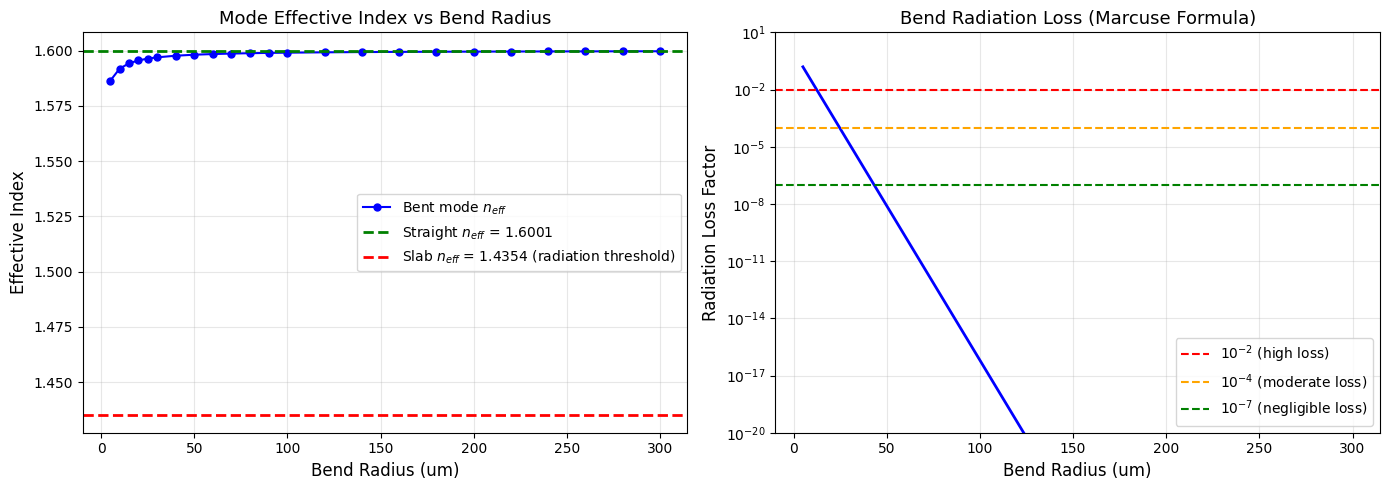


Minimum bend radius estimates (Marcuse analytical):
-------------------------------------------------------
  High loss (< -20 dB)            R >   12.3 um
  Low loss (< -40 dB)             R >   24.7 um
  Very low (< -70 dB)             R >   43.2 um
  Negligible (< -100 dB)          R >   61.7 um


In [5]:
# ─── Analytical bend loss (Marcuse formula) ───
#
# The radiation loss from a bent waveguide is dominated by:
#   alpha ~ exp( -2 * gamma^3 * R / (3 * beta^2) )
#
# where:
#   beta  = k0 * n_eff          (propagation constant)
#   gamma = k0 * sqrt(n_eff^2 - n_slab^2)  (lateral decay rate)
#
# For a 90-degree bend, the total loss is proportional to:
#   Loss_90 ~ (pi*R/2) * alpha    (arc length * loss per unit length)

k0    = 2 * np.pi / wavelength
beta  = k0 * n_eff_fund
gamma = k0 * np.sqrt(n_eff_fund**2 - n_slab**2)

print(f'k0    = {k0:.4f} rad/um')
print(f'beta  = {beta:.4f} rad/um')
print(f'gamma = {gamma:.4f} 1/um')
print(f'1/gamma = {1/gamma:.3f} um  (lateral 1/e decay length)')
print()

# Compute loss vs radius
R_fine = np.linspace(5, 300, 1000)
exponent = 2 * gamma**3 * R_fine / (3 * beta**2)

# Loss per unit length (arb. normalization; shape is what matters)
alpha = np.exp(-exponent) / np.sqrt(R_fine)

# Loss per 90-degree bend (arc = pi*R/2)
loss_90 = alpha * np.pi * R_fine / 2

# Normalize: set the loss at R=5 um to ~100 dB (clearly unacceptable)
# This gives us an approximate absolute scale
loss_90_dB = 10 * np.log10(loss_90 / loss_90[0] + 1e-300) + 100  # offset so R=5 ~ 100 dB

# ── Plot 1: n_eff vs bend radius ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(radii, n_eff_bent, 'bo-', markersize=5, label='Bent mode $n_{eff}$')
ax1.axhline(n_eff_fund, color='green', ls='--', lw=2,
            label=f'Straight $n_{{eff}}$ = {n_eff_fund:.4f}')
ax1.axhline(n_slab, color='red', ls='--', lw=2,
            label=f'Slab $n_{{eff}}$ = {n_slab:.4f} (radiation threshold)')
ax1.set_xlabel('Bend Radius (um)', fontsize=12)
ax1.set_ylabel('Effective Index', fontsize=12)
ax1.set_title('Mode Effective Index vs Bend Radius', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Radiation loss factor ──
ax2 = axes[1]
ax2.semilogy(R_fine, np.exp(-exponent), 'b-', linewidth=2)
ax2.axhline(1e-2,  color='red',    ls='--', label='$10^{-2}$ (high loss)')
ax2.axhline(1e-4,  color='orange', ls='--', label='$10^{-4}$ (moderate loss)')
ax2.axhline(1e-7,  color='green',  ls='--', label='$10^{-7}$ (negligible loss)')
ax2.set_xlabel('Bend Radius (um)', fontsize=12)
ax2.set_ylabel('Radiation Loss Factor', fontsize=12)
ax2.set_title('Bend Radiation Loss (Marcuse Formula)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(1e-20, 10)

plt.tight_layout()
plt.show()

# ── Find threshold radii ──
print('\nMinimum bend radius estimates (Marcuse analytical):')
print('-' * 55)
for label, threshold in [('High loss (< -20 dB)', 1e-2),
                          ('Low loss (< -40 dB)',  1e-4),
                          ('Very low (< -70 dB)',  1e-7),
                          ('Negligible (< -100 dB)', 1e-10)]:
    R_thresh = 3 * beta**2 / (2 * gamma**3) * np.log(1/threshold)
    print(f'  {label:30s}  R > {R_thresh:6.1f} um')

17:35:48 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

17:35:50 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

17:35:52 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

17:35:54 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

17:35:56 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.

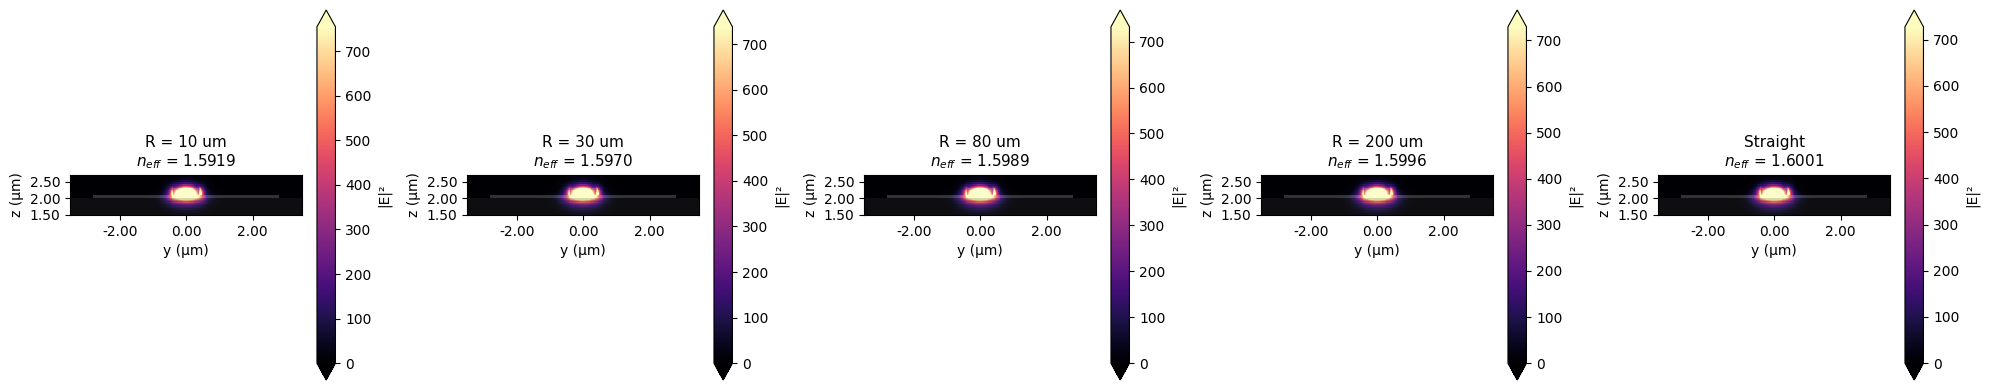

In [6]:
# ─── Mode profiles at selected bend radii ───
# Shows how the mode shifts outward as the bend gets tighter

radii_show = [10, 30, 80, 200, None]  # None = straight
fig, axes = plt.subplots(1, len(radii_show), figsize=(4*len(radii_show), 4))

for ax, R in zip(axes, radii_show):
    if R is None:
        spec = td.ModeSpec(num_modes=1, target_neff=n_LN)
        title = 'Straight'
    else:
        spec = td.ModeSpec(num_modes=1, target_neff=n_LN,
                           bend_radius=R, bend_axis=0)
        title = f'R = {R} um'
    
    ms = ModeSolver(
        simulation=sim, plane=plane,
        mode_spec=spec, freqs=[freq],
    )
    md = ms.solve()
    neff_val = np.real(md.n_eff.values[0, 0])
    
    # Try to plot the mode field
    try:
        ms.plot_field('E', 'abs^2', mode_index=0, f=freq, ax=ax)
    except Exception:
        try:
            ms.plot_field('Ex', 'abs^2', mode_index=0, f=freq, ax=ax)
        except Exception:
            ax.text(0.5, 0.5, f'n_eff={neff_val:.4f}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    ax.set_title(f'{title}\n$n_{{eff}}$ = {neff_val:.4f}', fontsize=11)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(1.5, 2.7)

plt.tight_layout()
plt.show()

In [7]:
# ─── Summary & Recommendations ───

# The R_min for negligible loss
R_safe = 3 * beta**2 / (2 * gamma**3) * np.log(1/1e-7)
R_conservative = 3 * beta**2 / (2 * gamma**3) * np.log(1/1e-10)

print('=' * 60)
print('SUMMARY: Minimum Bend Radius for LNOI Rib Waveguide')
print('=' * 60)
print(f'\nWaveguide: {rib_w} um rib, {film_h*1e3:.0f}/{slab_h*1e3:.0f} nm film/slab')
print(f'Straight n_eff = {n_eff_fund:.4f}')
print(f'Slab n_eff     = {n_slab:.4f}')
print(f'Lateral decay  = 1/gamma = {1/gamma:.2f} um')
print(f'\nRecommended minimum bend radii:')
print(f'  Very low loss (< 0.01 dB/bend):  R > {R_safe:.0f} um')
print(f'  Conservative  (< 0.001 dB/bend): R > {R_conservative:.0f} um')
print(f'\nYour current design uses R = 100 um (90-deg Euler bends).')
if 100 > R_safe:
    print(f'  -> 100 um is ABOVE the {R_safe:.0f} um threshold. Good!')
else:
    print(f'  -> 100 um is BELOW the {R_safe:.0f} um threshold. Consider increasing.')

print(f'\n--- Euler bend note ---')
print(f'These estimates are for CIRCULAR bends (worst case).')
print(f'Euler bends gradually transition curvature 0 -> 1/R_min,')
print(f'so they have LESS loss than circular bends at the same R_min.')
print(f'Your actual Euler bend loss will be lower than these estimates.')

SUMMARY: Minimum Bend Radius for LNOI Rib Waveguide

Waveguide: 0.8 um rib, 300/100 nm film/slab
Straight n_eff = 1.6001
Slab n_eff     = 1.4354
Lateral decay  = 1/gamma = 0.35 um

Recommended minimum bend radii:
  Very low loss (< 0.01 dB/bend):  R > 43 um
  Conservative  (< 0.001 dB/bend): R > 62 um

Your current design uses R = 100 um (90-deg Euler bends).
  -> 100 um is ABOVE the 43 um threshold. Good!

--- Euler bend note ---
These estimates are for CIRCULAR bends (worst case).
Euler bends gradually transition curvature 0 -> 1/R_min,
so they have LESS loss than circular bends at the same R_min.
Your actual Euler bend loss will be lower than these estimates.
